In [1]:
using Plots
using StatsFuns

Quick sanity check: Given `turnbias` affects both stay/go as well as, conditional on go, the left/right choice, can we independently bias stay/go and left/right?

Left/right is simple:
\begin{align}
q=\frac{1}{1 + e^{Q_2 - Q_3 + \text{turnbias}}}
\end{align}

We can set the softmax output to any arbitrary $q$ by adjusting $\text{turnbias}$

Now given $\text{turnbias}$, what about our stay/go? 

\begin{align}
p=\frac{1}{1 + e^{Q_2 + \text{turbias} - Q_1 - \text{staybias}} + e^{Q_3 - Q_1 - \text{staybias}}}
\end{align}

The $\text{turnbias}$ term here really can be integrated into $Q_2$, so we're just adding in a stay bias as normal, ignoring the turn bias, which definitely should cover the stay/go space properly.

Not quite sure what the precise relationship is - assuming it's not a linear relationship between $\text{turbias}$ and $\text{staybias}$, but the overall interpretation here is that $\text{turnbias}$ should purely capture the left/right choice, and $\text{staybias}$ is doing double duty on compensating for $\text{turnbias}$ as well as stay/go, but there exists some parameterization that achieves both.


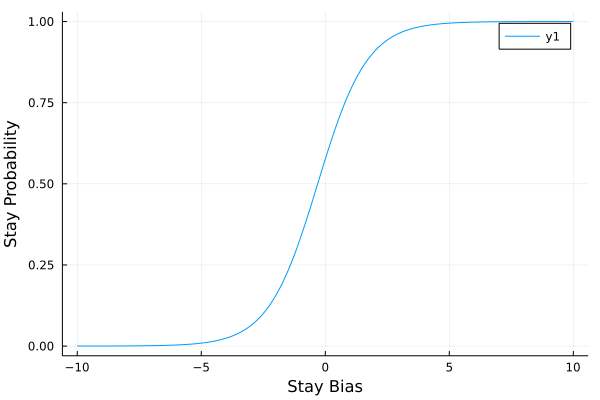

In [9]:
a = 3.0
b = 2.0
c = 2.0
staybias = -10:0.1:10

ps = zeros(length(staybias))
for i in 1:length(staybias)
    ax = a + staybias[i]
    ps[i] = exp(ax) / (exp(ax) + exp(b) + exp(c))
end
plot(staybias,ps)
xlabel!("Stay Bias")
ylabel!("Stay Probability")

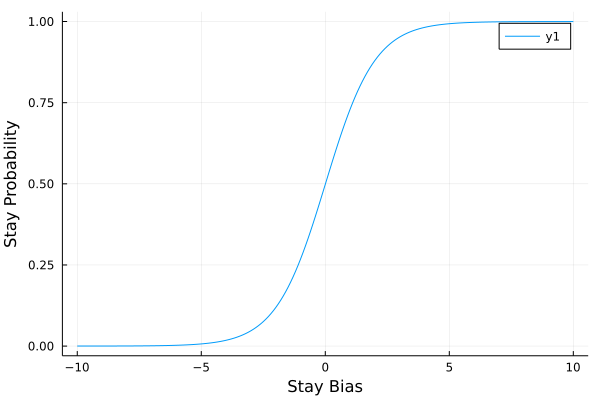

In [8]:
a = 5.0
b = 5.0
c = 0.0
staybias = -10:0.1:10

ps = zeros(length(staybias))
for i in 1:length(staybias)
    ax = a + staybias[i]
    ps[i] = exp(ax) / (exp(ax) + exp(b) + exp(c))
end
plot(staybias,ps)
xlabel!("Stay Bias")
ylabel!("Stay Probability")

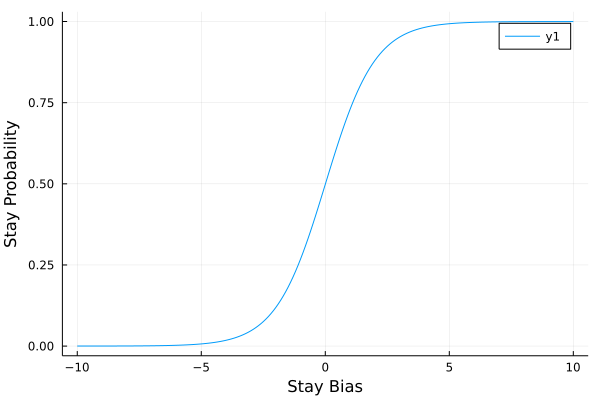

In [6]:
a = 5.0
b = 0.0
c = 5.0
staybias = -10:0.1:10

ps = zeros(length(staybias))
for i in 1:length(staybias)
    ax = a + staybias[i]
    ps[i] = exp(ax) / (exp(ax) + exp(b) + exp(c))
end
plot(staybias,ps)
xlabel!("Stay Bias")
ylabel!("Stay Probability")

## Three-Parameter Spatial Turn Bias

However, I don't think this is as clear-cut when we want to model a separate turn bias for each stem:

If we think of each of the three turn biases as independently affecting the left/right choices, we're now left with `staybias` having to compensate for all three, which it obviously can't do.

Given the general importance of capturing the stay/go behavior in the models, the downstream effect of this is probably not going to be an impact on `staybias` as much as pulling in the three `spatialbias` parameters to reduce their effect on stay/go